In [22]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn import linear_model
from sklearn.metrics import r2_score

In [2]:
data = pd.read_csv('Car_Stopping_Distance.csv')

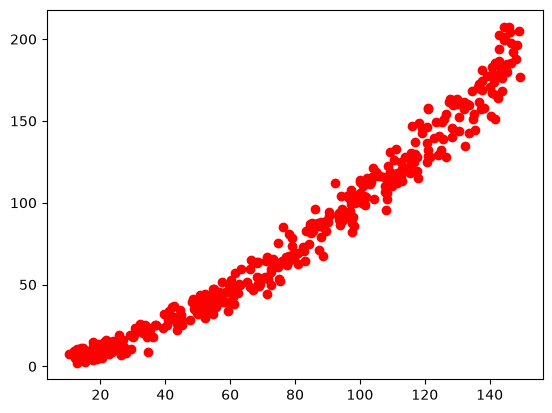

In [3]:
plt.scatter(data.SPEED_KMH,data.STOPPING_DISTANCE_M, color='red')

###### im seeing a curve in the data, i know that i can still use simple linear regression for it but i know i can achive a better r2 if i use the non linear regression model

In [4]:
mask = np.random.rand(len(data)) < 0.8
train = data[mask]
test = data[~mask]
X = "SPEED_KMH"
Y = "STOPPING_DISTANCE_M"

In [5]:
train_x = np.asanyarray(train[[X]])
train_y = np.asanyarray(train[[Y]])
test_x = np.asanyarray(test[[X]])
test_y = np.asanyarray(test[[Y]])

# simple linear regression

In [6]:
simpleregr = linear_model.LinearRegression()
simpleregr.fit(train_x,train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.36]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-27.65]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[733.8]


# non linear regression

In [7]:
nonlinear = linear_model.LinearRegression()
speed_squared = train_x **2
speed_poly = np.hstack([train_x,speed_squared])
nonlinear.fit(speed_poly,train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 2)","[[0.46,0.01]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.82]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[120627.68, 162.32]"


# predict both models

In [17]:
test_speed_squared = test_x **2
test_speed_poly = np.hstack([test_x,test_speed_squared])

In [18]:
simple_test_out = simpleregr.predict(test_x)
nonlinear_test_out = nonlinear.predict(test_speed_poly)

# test the len of vars


In [19]:
print(f"""test_x {len(test_x)}
test_y {len(test_y)}
nonlinear_test_out {len(nonlinear_test_out)}""")

test_x 80
test_y 80
nonlinear_test_out 80


# check the model's answers

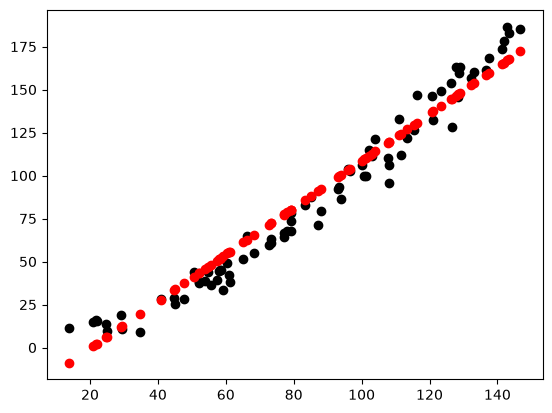

In [13]:
plt.scatter(test_x,test_y,color='black')
plt.scatter(test_x,simple_test_out,color='red')

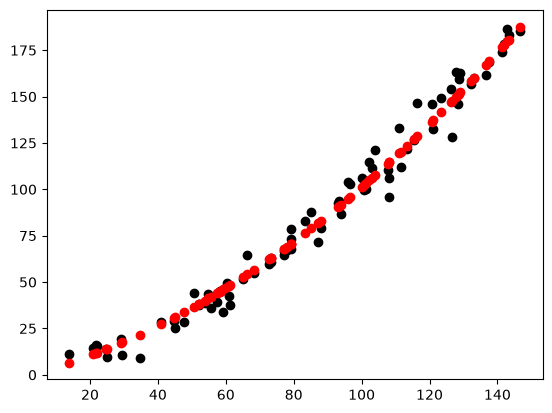

In [20]:
plt.scatter(test_x,test_y,color='black')
plt.scatter(test_x, nonlinear_test_out, color='red')

In [23]:
simplelinear_r2_score = r2_score(test_y,simple_test_out)
nonlinear_r2_score = r2_score(test_y,nonlinear_test_out)

print(f"""simple linear model r2 score: {simplelinear_r2_score}
non linear model r2 score: {nonlinear_r2_score}""")

simple linear model r2 score: 0.9593316696716273
non linear model r2 score: 0.9821028404758481


###  non linear model answer vs simple linear model answer

In [27]:
Speed_KMH = 120
Speed_KMH_squared = Speed_KMH ** 2

nonlinear_answer = nonlinear.intercept_[0] + nonlinear.coef_[0][0] * Speed_KMH + nonlinear.coef_[0][1] * Speed_KMH_squared
simplelinear_answer = simpleregr.coef_[0][0] * Speed_KMH + simpleregr.intercept_[0]

print(f"""non linear model answer: {nonlinear_answer}
simple linear answer {simplelinear_answer}""")

non linear model answer: 135.2938925226686
simple linear answer 135.8321949783569
